## Step 1: Data Loading and Initial Inspection

### Initial Data Loading and Inspection

This section focuses on loading the dataset and performing an initial inspection to understand its structure and content. We load the CSV file into a pandas DataFrame and display the first few rows to get a quick overview of the data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
file_path = '/content/hatevsoffensive_language.csv'
df = pd.read_csv(file_path)

# 2. Initial Inspection
display(df.head())

,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
print("\n--- Dataset Info ---")
df.info()


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   24783 non-null  object
 1   text    24783 non-null  object
dtypes: object(2)
memory usage: 387.4+ KB


## Step 2: Exploratory Data Analysis — Class Distribution

### Class Distribution Analysis

Before training the model, it is essential to evaluate how the target classes are distributed. When a dataset is imbalanced—meaning certain categories contain far more samples than others—the resulting model may develop a bias, performing accurately on the majority class while failing to recognize minority patterns.

This section performs the following steps to assess data balance:

1.   Frequency Calculation: Tabulates the exact count for each class label.
2.   Data Visualization: Generates a bar plot to provide a clear, comparative view of the labels.


Identifying these discrepancies early allows you to decide if intervention strategies, such as applying class_weight adjustments or resampling techniques, are necessary to ensure fair model performance across all categories.

In [4]:
# 3. Check for Class Imbalance
target_column = 'label'
print("\n--- Class Distribution ---")
class_counts = df[target_column].value_counts()
print(class_counts)


--- Class Distribution ---
label
offensive language    19190
neither                4163
hate speec             1430
Name: count, dtype: int64


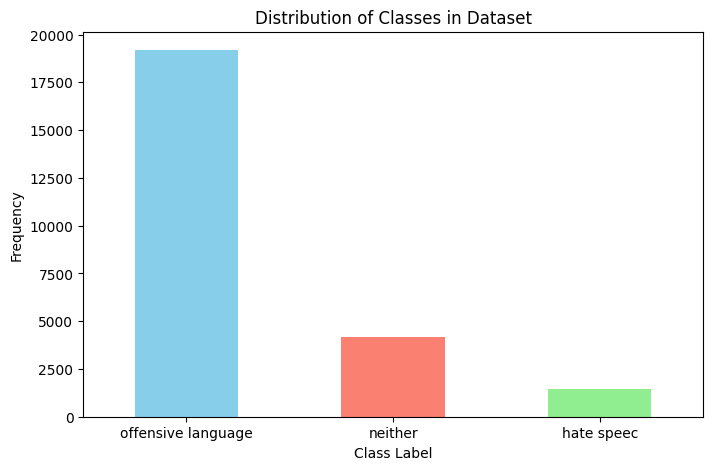

In [5]:
# Visualize the class distribution to include in your report
plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Distribution of Classes in Dataset')
plt.xlabel('Class Label')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

## Step 3: Text Preprocessing

### Text Preprocessing

In [6]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

stop_words = set(stopwords.words('english'))

# 2. Add custom Twitter-specific noise to your stopwords list
stop_words.update(['rt', 'amp'])

words_to_keep = {
    'not', 'no', 'nor', 'against', 'you', 'your', 'yours',
    'he', 'him', 'his', 'she', 'her', 'hers', 'they', 'them', 'their', 'theirs'
}

# 4. Remove these from your stop_words set
stop_words = stop_words - words_to_keep

lemmatizer = WordNetLemmatizer()

# Contractions dictionary
CONTRACTION_MAP = {
    "ain't": "is not", "aren't": "are not","can't": "cannot", "can't've": "cannot have",
    "'cause": "because", "could've": "could have","couldn't": "could not",
    "couldn't've": "could not have", "didn't": "did not", "doesn't": "do not",
    "don't": "do not", "hadn't": "had not", "hadn't've": "had not have",
    "hasn't": "has not", "haven't": "have not", "he'd": "he would",
    "he'd've": "he would have", "he'll": "he will", "he'll've": "he will have",
    "he's": "he is", "how'd": "how did", "how'd'y": "how do you",
    "how'll": "how will", "how's": "how is", "I'd": "I would",
    "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have",
    "I'm": "I am", "I've": "I have", "isn't": "is not", "it'd": "it would",
    "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have",
    "it's": "it is", "let's": "let us", "ma'am": "madam",
    "mayn't": "may not", "might've": "might have","mightn't": "might not",
    "mightn't've": "might not have", "must've": "must have",
    "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not",
    "needn't've": "need not have","o'clock": "of the clock", "oughtn't": "ought not",
    "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not",
    "shan't've": "shall not have", "she'd": "she would", "she'd've": "she would have",
    "she'll": "she will", "she'll've": "she will have", "she's": "she is",
    "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have",
    "so've": "so have","so's": "so as", "that'd": "that would",
    "that'd've": "that would have", "that's": "that is", "there'd": "there would",
    "there'd've": "there would have", "there's": "there is", "these's": "these is",
    "they'd": "they would", "they'd've": "they would have", "they'll": "they will",
    "they'll've": "they will have", "they're": "they are", "they've": "they have",
    "to've": "to have", "wasn't": "was not", "we'd": "we would",
    "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have",
    "we're": "we are", "we've": "we have", "weren't": "were not",
    "what'll": "what will", "what'll've": "what will have", "what're": "what are",
    "what's": "what is", "what've": "what have", "when's": "when is",
    "when've": "when have", "where'd": "where did", "where's": "where is",
    "where've": "where have", "who'll": "who will", "who'll've": "who will have",
    "who's": "who is", "who've": "who have", "why's": "why is",
    "why've": "why have", "will've": "will have", "won't": "will not",
    "won't've": "will not have", "would've": "would have", "wouldn't": "would not",
    "wouldn't've": "would not have", "y'all": "you all", "y'all'd": "you all would",
    "y'all'd've": "you all would have","y'all're": "you all are",
    "y'all've": "you all have", "you'd": "you would", "you'd've": "you would have",
    "you'll": "you will", "you'll've": "you will have", "you're": "you are",
    "you've": "you have"
}

def expand_contractions(text, contraction_mapping=CONTRACTION_MAP):
    contractions_pattern = re.compile('(' + '|'.join(contraction_mapping.keys()) + ')')
    def expand_match(contraction):
        match = contraction.group(0)
        expanded_contraction = contraction_mapping.get(match)
        if not expanded_contraction:
            expanded_contraction = contraction_mapping.get(match.lower())
        return expanded_contraction
    expanded_text = contractions_pattern.sub(expand_match, text)
    return expanded_text

def clean_text(text):
    text = expand_contractions(text)
    text = text.lower() # Lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'@\w+', '', text) # Remove mentions
    text = re.sub(r'#\w+', '', text) # Remove hashtags
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove special characters (keep only letters and spaces)
    text = text.strip() # Remove leading/trailing whitespace

    # Remove stopwords and lemmatize
    tokens = text.split()
    filtered_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    text = ' '.join(filtered_tokens)
    return text

df['cleaned_text'] = df['text'].apply(clean_text)

display(df[['text', 'cleaned_text']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,text,cleaned_text
0,!!! RT @mayasolovely: As a woman you shouldn't...,woman you not complain cleaning your house man...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,boy dat coldtyga dwn bad cuffin dat hoe st place
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,dawg you ever fuck bitch she start cry you con...
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,she look like tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,shit you hear might true might faker bitch tol...


### Text Preprocessing Steps

Text Preprocessing Workflow
In Natural Language Processing (NLP), raw text is often messy and inconsistent. The clean_text function acts as a pipeline to standardize this data, ensuring that machine learning models focus on the core meaning rather than noise.

Here is a breakdown of the transformations applied:


1.   Normalization & Cleaning:
*   Contraction Expansion: Standardizes terms (e.g., "don't" becomes "do not") for uniform representation.


*  Lowercasing: Ensures the model treats "Apple" and "apple" as the same token.
*   Whitespace Stripping: Eliminates unnecessary leading or trailing spaces.


2. Noise Elimination:

*   Social Media & Web Filters: Removes URLs, @mentions, and #hashtags which typically lack predictive value.

*  Character Filtering: Strips out numbers, punctuation, and special symbols, retaining only alphabetic text.
3.   Linguistic Refinement:


*   Stopword Removal: Filters out frequent but low-value words (e.g., "the," "is"). The process uses a custom list that ignores Twitter-specific noise (like 'rt') but preserves sentiment-critical words like "not."


* Lemmatization: Maps different forms of a word (e.g., "running," "ran") back to their dictionary root or "lemma" (e.g., "run"), significantly reducing vocabulary complexity.







## Step 4: Visualize Cleaned Data — Word Clouds

### Visualize Cleaned Data

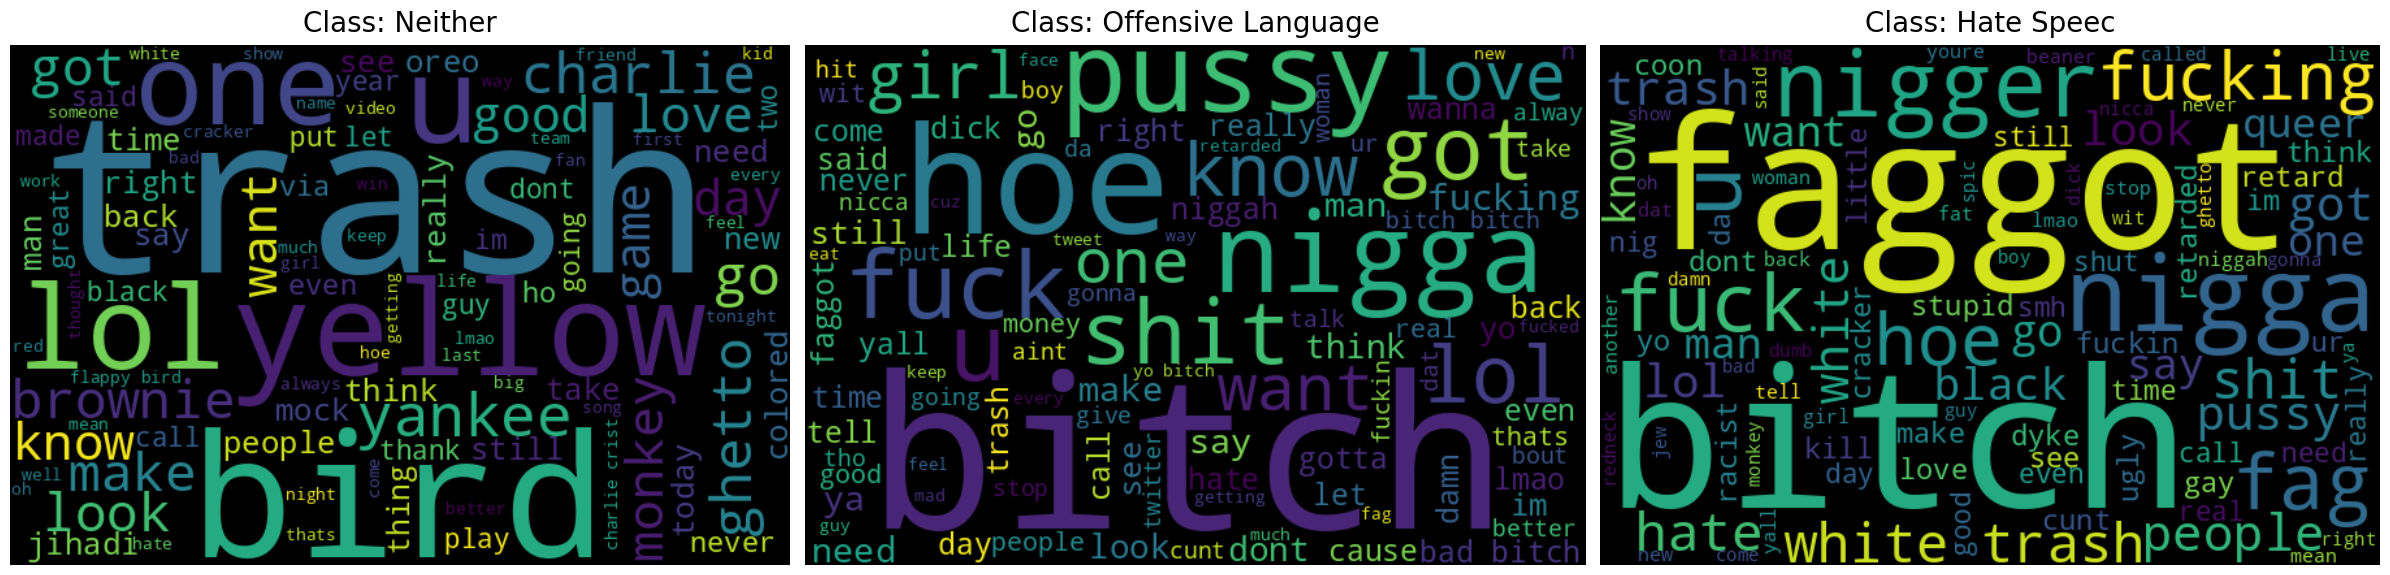

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Get the unique class
classes = df['label'].unique()

# Set up a large figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

for i, class_name in enumerate(classes):
    # 1. Filter the cleaned text for this specific class
    class_text = ' '.join(tweet for tweet in df[df['label'] == class_name]['cleaned_text'])

    # 2. Generate the Word Cloud
    # Using different colormaps can make them distinct, but keeping it uniform looks professional too
    wordcloud = WordCloud(width=600,
                          height=400,
                          background_color='black',
                          colormap='viridis',
                          max_words=100).generate(class_text)

    # 3. Plot onto the corresponding subplot
    axes[i].imshow(wordcloud, interpolation='bilinear')

    # Set a clean title, capitalizing the class name
    axes[i].set_title(f'Class: {class_name.title()}', fontsize=20, pad=10)
    axes[i].axis("off") # Turn off axis lines and numbers

# Adjust layout so they don't overlap and display!
plt.tight_layout()
plt.show()

/tmp/ipykernel_1103/1514449253.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=words_df, palette='magma')


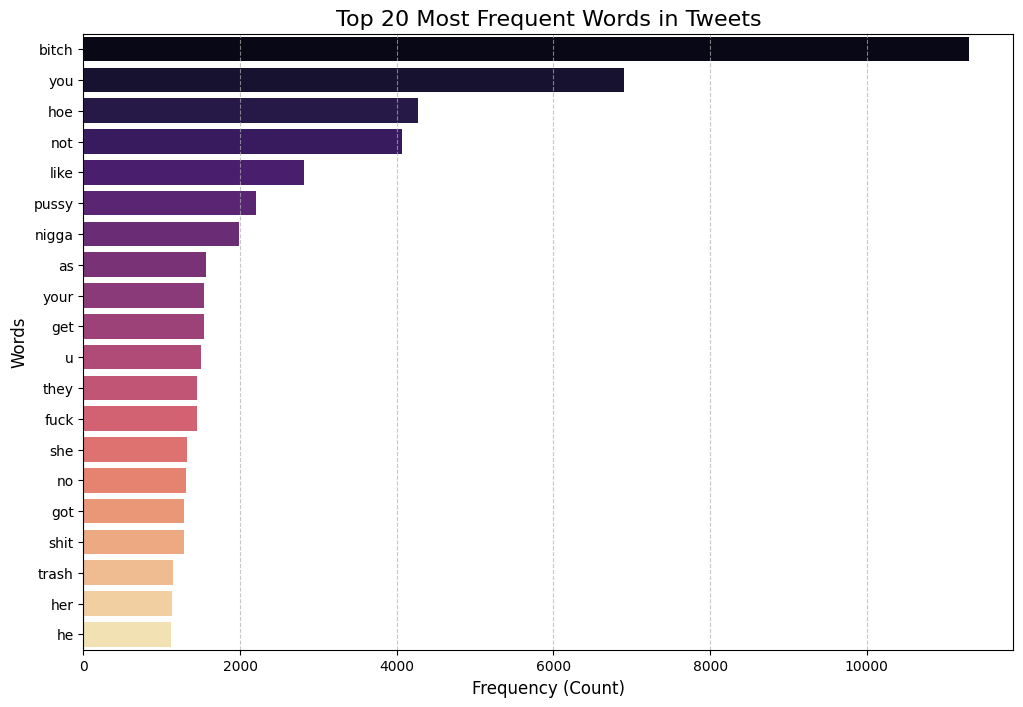

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

# 1. Combine all cleaned text into one large list of words
all_words = ' '.join(df['cleaned_text']).split()

# 2. Count the frequency of each word
word_freq = Counter(all_words)

# 3. Get the top 20 most common words
# You can change 20 to any number you prefer
common_words = word_freq.most_common(20)

# 4. Convert to a DataFrame for easier plotting
words_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

# 5. Plotting
plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Word', data=words_df, palette='magma')

plt.title('Top 20 Most Frequent Words in Tweets', fontsize=16)
plt.xlabel('Frequency (Count)', fontsize=12)
plt.ylabel('Words', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Step 5: Train/Test Split, Tokenization, and Padding

### Tokenization and Padding

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Define Features (X) and Target (y)
# Using the integer-encoded 'target'
X = df['cleaned_text'].values
y = df['label'].values

# 2. Train/Test Split
# stratify=y ensures the class imbalance is preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# 3. Tokenization
MAX_VOCAB_SIZE = 10000
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")

# Fit the tokenizer ONLY on the training data to prevent data leakage
tokenizer.fit_on_texts(X_train)

# Convert text to sequences of integers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# 4. Percentile-Based Padding
# Calculate the length of all training sequences
seq_lengths = [len(seq) for seq in X_train_seq]

# Find the 95th percentile length (keeps most data, drops massive outliers)
MAX_LEN = int(np.percentile(seq_lengths, 95))
print(f"\n95th Percentile Sequence Length (MAX_LEN): {MAX_LEN}")

# Apply padding
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Shape of X_train_pad: {X_train_pad.shape}")
print(f"Shape of X_test_pad: {X_test_pad.shape}")

Training samples: 19826
Testing samples: 4957

95th Percentile Sequence Length (MAX_LEN): 16
Shape of X_train_pad: (19826, 16)
Shape of X_test_pad: (4957, 16)


### Tokenization and Padding

After cleaning the text, the next step is to convert the strings into a numerical format that a neural network can process. This involves mapping words to integers and ensuring all inputs share the same dimensions.



1.   Dataset Partitioning

*  Feature/Target Assignment: The cleaned_text serves as the input feature ($X$), while the label serves as the target output ($y$).

*   Stratified Splitting: We split the data into training and testing sets using stratify=y. This preserves the original class distribution in both subsets, preventing the model from being trained or evaluated on a biased sample.
2.   Vectorization via Tokenization

The Keras Tokenizer transforms raw text into sequences of integers.

*   Vocabulary Management: MAX_VOCAB_SIZE restricts the model to the most frequent words, while an <OOV> (Out-Of-Vocabulary) token handles any words encountered during testing that weren't seen during training.


*   Preventing Leakage: The tokenizer is fitted exclusively on the training data. This ensures the model doesn't "peek" at the vocabulary or word frequencies of the test set, maintaining a rigorous evaluation

3.   Standardizing Length through Padding

Neural networks typically require fixed-length input vectors. We use pad_sequences to create a uniform shape.

*   Defining MAX_LEN: Instead of using the absolute maximum length, we use the 95th percentile of training sequence lengths. This captures the vast majority of data while ignoring outliers that would make the input matrices unnecessarily sparse.
*   Post-Padding/Truncating: If a sequence is too short, we append zeros to the end (padding='post'). If it exceeds the limit, we trim it from the end (truncating='post').








## Step 6: Label Encoding

### Label Encoding

Neural networks require numerical targets. Since our labels are strings ('hate speech', 'neither', 'offensive language'), we use LabelEncoder to map them to integers.

*   Fitting: The encoder learns the unique categories from the training set.

*   Transforming: Both training and testing labels are converted into integers. This format is compatible with the sparse_categorical_crossentropy loss function.
*  Verification: We check le.classes_ to confirm the mapping and preview the first 10 encoded labels to ensure accuracy.



In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_train)

y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

print('Label classes:', le.classes_)
print('Sample encoded labels:', y_train_enc[:10])

Label classes: ['hate speec' 'neither' 'offensive language']
Sample encoded labels: [2 0 2 2 2 2 2 2 2 1]


## Step 7: Load Pre-trained GloVe Embeddings

### Load Pre-trained Word Embeddings (GloVe)

To enrich the model with a deeper understanding of linguistic relationships, we incorporate GloVe (Global Vectors for Word Representation). This unsupervised learning algorithm provides pre-calculated vector representations for words, allowing the model to leverage existing knowledge of how terms relate to one another semantically. By downloading a pre-trained GloVe model and constructing an embedding matrix, we effectively map the specific vocabulary from our dataset to these high-dimensional vectors. This process ensures the neural network starts with a sophisticated grasp of language rather than learning every word association from scratch.

In [11]:
!pip install gensim

import gensim.downloader as api
import numpy as np

# It will only download the first time you run it.
print("Fetching GloVe vectors from API...")
glove_model = api.load("glove-wiki-gigaword-50")
print("Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 77.1 MB/s eta 0:00:00
Fetching GloVe vectors from API...
[==================================================] 100.0% 66.0/66.0MB downloaded
Done!


## Step 8: Build Models

### Model 1: Simple RNN Architecture

This section defines and compiles the first neural network model, a Simple Recurrent Neural Network (RNN).

*   **`Input(shape=(MAX_LEN,))`**: Defines the input shape for the model, which is a sequence of integers of length `MAX_LEN`.
*   **`Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM)`**: This layer converts integer-encoded words into dense vectors of fixed size (`EMBEDDING_DIM`). `VOCAB_SIZE` is the total number of unique words in our vocabulary. This layer learns embeddings from scratch.
*   **`SimpleRNN(64, return_sequences=False)`**: A basic RNN layer with 64 units. `return_sequences=False` means it outputs only the last hidden state for each sequence, suitable for classification tasks.
*   **`Dense(32, activation='relu')`**: A fully connected layer with 32 units and ReLU activation, providing non-linearity.
*   **`Dense(3, activation='softmax')`**: The output layer with 3 units (corresponding to our 3 classes) and softmax activation to output probability distributions over the classes.

The model is compiled with the Adam optimizer, `sparse_categorical_crossentropy` loss (because our labels are integer-encoded), and `accuracy` as a metric.

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, LSTM, Dense, Dropout, SpatialDropout1D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Parameters for our Embedding Layer
VOCAB_SIZE = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)
EMBEDDING_DIM = 100

# ==========================================
# MODEL 1: Simple RNN
# ==========================================
model1_rnn = Sequential([
    Input(shape=(MAX_LEN,)),


    Embedding(input_dim=VOCAB_SIZE,
              output_dim=EMBEDDING_DIM,
              mask_zero=True),

    SpatialDropout1D(0.2),

    SimpleRNN(32, return_sequences=False, dropout=0.2, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation='relu'),
    # reomve dropout since model overfits
    Dense(3, activation='softmax')
])

model1_rnn.compile(optimizer=Adam(learning_rate=0.0002),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

print("--- Model 1: Simple RNN Summary ---")
model1_rnn.summary()

--- Model 1: Simple RNN Summary ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 16, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 16, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         4,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,004,963 (3.83 MB)

 Trainable params: 1,004,899 (3.83 MB)

 Non-trainable params: 64 (256.00 B)

### Model 2: LSTM Architecture

This section defines and compiles the second neural network model, a Long Short-Term Memory (LSTM) network. LSTMs are a type of RNN that are particularly good at learning long-term dependencies due to their internal gate mechanisms, which help in mitigating the vanishing gradient problem.

*   **`Input(shape=(MAX_LEN,))`**: Same input as the Simple RNN.
*   **`Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM)`**: Similar to Model 1, this layer learns word embeddings from scratch.
*   **`LSTM(64, return_sequences=False)`**: An LSTM layer with 64 units. Like Simple RNN, `return_sequences=False` means it outputs the final hidden state for classification.
*   **`Dense(32, activation='relu')`**: A dense hidden layer with ReLU activation.
*   **`Dense(3, activation='softmax')`**: The output layer for 3-class classification.

The model is compiled with the Adam optimizer, `sparse_categorical_crossentropy` loss, and `accuracy` as a metric.

In [13]:
# ==========================================
# MODEL 2: LSTM
# ==========================================
model2_lstm = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=EMBEDDING_DIM),

    SpatialDropout1D(0.2),                       # Drops entire embedding dimensions

    LSTM(64,
         return_sequences=False,
         dropout=0.2,                            # Input dropout
         recurrent_dropout=0.1,                  # Recurrent dropout
         kernel_regularizer=l2(1e-4)),           # L2 weight regularization

    BatchNormalization(),

    Dropout(0.3),

    Dense(32, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

model2_lstm.compile(optimizer=Adam(learning_rate=0.0002),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

print("\n--- Model 2: LSTM Summary ---")
model2_lstm.summary()


--- Model 2: LSTM Summary ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 16, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 16, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,044,675 (3.99 MB)

 Trainable params: 1,044,547 (3.98 MB)

 Non-trainable params: 128 (512.00 B)

### Model 3: LSTM with Pre-trained GloVe Embeddings Architecture

This section defines and compiles the third neural network model, an LSTM network leveraging pre-trained GloVe word embeddings. Using pre-trained embeddings allows the model to benefit from semantic relationships learned from a much larger corpus, even with a relatively small custom dataset.

*   **`Input(shape=(MAX_LEN,))`**: Same input as the previous models.
*   **`Embedding(input_dim=VOCAB_SIZE, output_dim=GLOVE_DIM, weights=[embedding_matrix], trainable=False)`**: This is the key difference. Instead of learning embeddings from scratch, this layer is initialized with our `embedding_matrix` (derived from GloVe). `GLOVE_DIM` is the dimensionality of the GloVe vectors (50 in this case). `trainable=False` freezes these weights, meaning the pre-trained embeddings will not be updated during training, preserving their rich semantic information.
*   **`LSTM(64, return_sequences=False)`**: An LSTM layer with 64 units.
*   **`Dense(32, activation='relu')`**: A dense hidden layer with ReLU activation.
*   **`Dense(3, activation='softmax')`**: The output layer for 3-class classification.

The model is compiled with the Adam optimizer, `sparse_categorical_crossentropy` loss, and `accuracy` as a metric.

In [14]:
import gensim.downloader as api
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

# 1. Load the model
GLOVE_DIM = 50
print("Loading GloVe vectors from API... this may take a minute.")
glove_model = api.load(f"glove-twitter-{GLOVE_DIM}")
print("Done!")

# 2. Build the embedding matrix
word_index = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))

matched, unmatched = 0, 0
for word, i in word_index.items():
    if i >= VOCAB_SIZE:
        continue
    if word in glove_model:
        embedding_matrix[i] = glove_model[word]
        matched += 1
    else:
        unmatched += 1

print(f'Words matched: {matched} | Words NOT found: {unmatched}')

# 3. Your LSTM Model
model3_lstm_w2v = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(input_dim=VOCAB_SIZE,
              output_dim=GLOVE_DIM,
              weights=[embedding_matrix],
              mask_zero=True,
              trainable=True),  # Keeps the pretrained weights frozen

    SpatialDropout1D(0.2),

    LSTM(64,dropout=0.2, recurrent_dropout=0.1),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax') # Assuming 3 classes: Hate, Offensive, Neither
])

model3_lstm_w2v.compile(optimizer=Adam(learning_rate=0.0001),
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

model3_lstm_w2v.summary()

Loading GloVe vectors from API... this may take a minute.
[==================================================] 100.0% 199.5/199.5MB downloaded
Done!
Words matched: 9094 | Words NOT found: 905


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 16, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 16, 50)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531,619 (2.03 MB)

 Trainable params: 531,619 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

## Step 9: Train All Models

### Model Training and Metrics

This section is responsible for training the three defined models (Simple RNN, LSTM, and LSTM with GloVe embeddings). Each model is trained using the `fit` method with the following key parameters:

*   **`X_train_pad` and `y_train_enc`**: The padded training data and encoded training labels.
*   **`epochs=20`**: The maximum number of training iterations. Training will stop earlier if `EarlyStopping` criteria are met.
*   **`batch_size=64`**: The number of samples processed before the model's internal parameters are updated.
*   **`validation_split=0.1`**: 10% of the training data is reserved for validation during training. This helps monitor the model's performance on unseen data and detect overfitting.
*   **`callbacks=[early_stop]`**: The `EarlyStopping` callback is used to prevent overfitting and optimize training time. It monitors the `val_loss` (validation loss) and stops training if it doesn't improve for `patience=3` epochs. `restore_best_weights=True` ensures that the model weights from the epoch with the best validation loss are restored.

The training time for each model is also recorded and printed for comparison.

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import time

# ==========================================
# COMPUTE CLASS WEIGHTS
# ==========================================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_enc),
    y=y_train_enc
)
class_weight_dict = dict(enumerate(class_weights))

print("📊 Computed Class Weights:")
for cls_idx, weight in class_weight_dict.items():
    print(f"   Class {cls_idx}: {weight:.3f}")


early_stop = EarlyStopping(monitor='val_loss', patience=9,min_delta=0.001,restore_best_weights=True, verbose=1)

EPOCHS     = 20
BATCH_SIZE = 128

# ── Train Model 1: Simple RNN ──────────────────────────────────────────
print('=' * 50)
print('Training Model 1: Simple RNN')
print('=' * 50)
start1   = time.time()
history1 = model1_rnn.fit(
    X_train_pad, y_train_enc,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)
time1 = time.time() - start1
print(f'\nModel 1 training time: {time1:.2f} seconds')


# ── Train Model 2: LSTM ────────────────────────────────────────────────
print('\n' + '=' * 50)
print('Training Model 2: LSTM')
print('=' * 50)
start2   = time.time()
history2 = model2_lstm.fit(
    X_train_pad, y_train_enc,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)
time2 = time.time() - start2
print(f'\nModel 2 training time: {time2:.2f} seconds')


# ── Train Model 3: LSTM + GloVe ────────────────────────────────────────
print('\n' + '=' * 50)
print('Training Model 3: LSTM + GloVe Embeddings')
print('=' * 50)
start3   = time.time()
history3 = model3_lstm_w2v.fit(
    X_train_pad, y_train_enc,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)
time3 = time.time() - start3
print(f'\nModel 3 training time: {time3:.2f} seconds')

print('\n✅ All models trained successfully!')
print(f'Times — RNN: {time1:.1f}s | LSTM: {time2:.1f}s | LSTM+GloVe: {time3:.1f}s')


📊 Computed Class Weights:
   Class 0: 5.777
   Class 1: 1.985
   Class 2: 0.430
Training Model 1: Simple RNN
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.2667 - loss: 1.3191 - val_accuracy: 0.5693 - val_loss: 1.0450
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4375 - loss: 1.0540 - val_accuracy: 0.7373 - val_loss: 0.8435
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5843 - loss: 0.8937 - val_accuracy: 0.7711 - val_loss: 0.7122
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6722 - loss: 0.7739 - val_accuracy: 0.7670 - val_loss: 0.6940
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7227 - loss: 0.6805 - val_accuracy: 0.7973 - val_loss: 0.6185
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7514 - loss: 0.5922 - val_accuracy: 0.7806 - val_loss: 0.6355
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7804 - loss: 0.5128 - val_accuracy: 0.8094 - val_loss: 

## Step 10: Visualize Training History

### Visualize Training History

This section provides a visual analysis of how each model performed during training. The `plot_history` function takes a model's training history and plots the training and validation loss, as well as training and validation accuracy, over epochs.

*   **Loss Curves**: Show how well the model is learning on both the training and validation sets. A decreasing trend is desirable. A significant gap between training and validation loss often indicates overfitting.
*   **Accuracy Curves**: Show the classification accuracy on both sets. Similar to loss, a large divergence suggests overfitting.

These plots are crucial for understanding model convergence, identifying overfitting or underfitting, and comparing the learning behavior of different architectures. The plots are saved as `training_curves.png`.

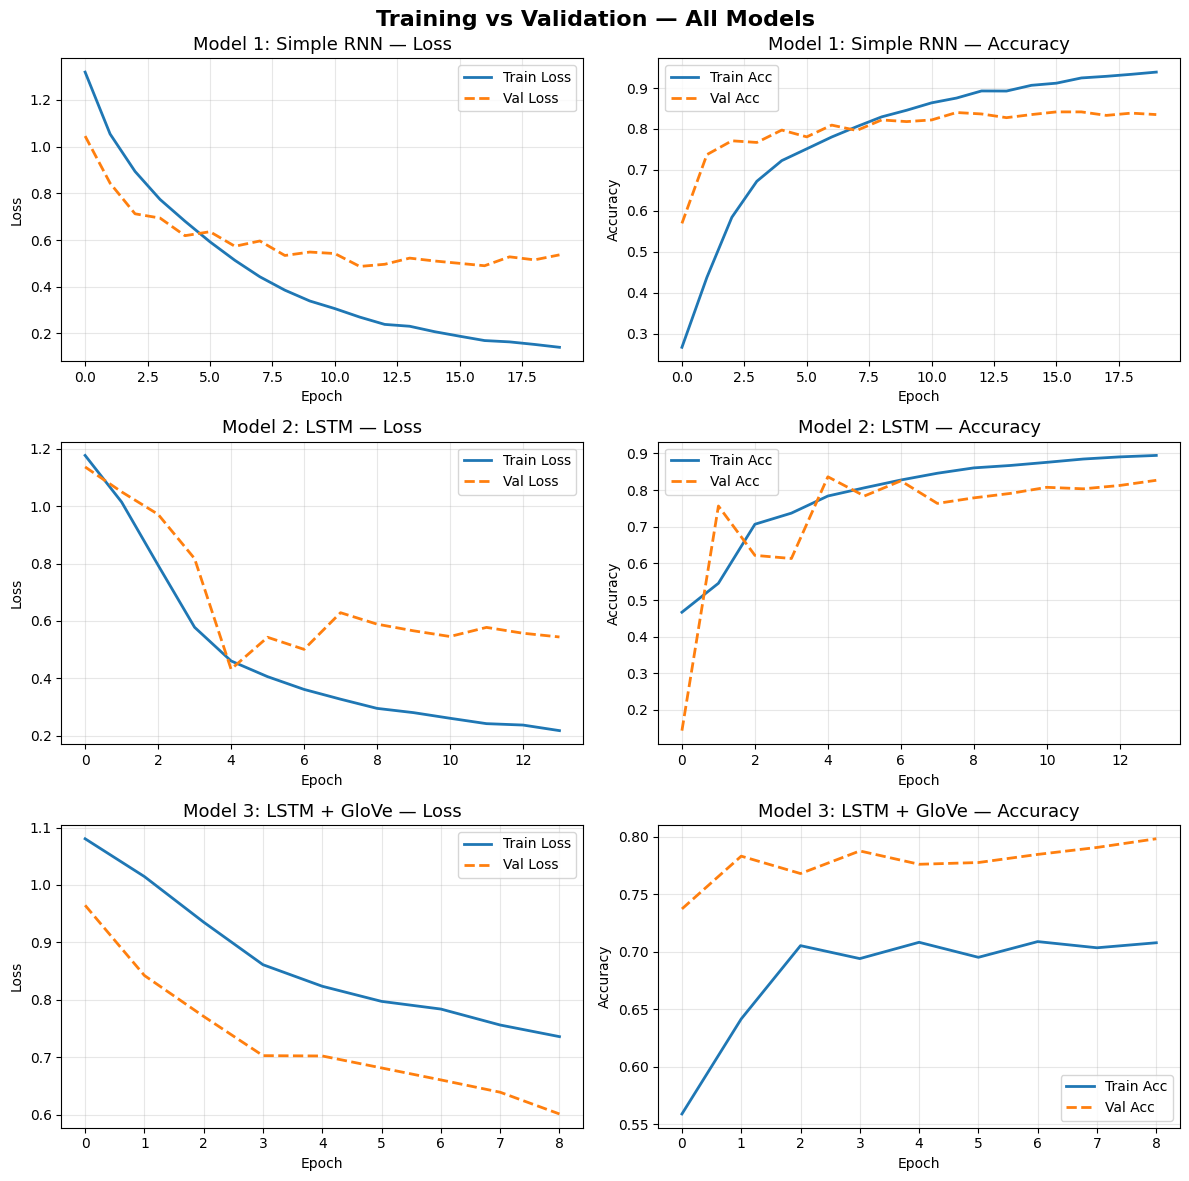

Saved: training_curves.png


In [16]:
import matplotlib.pyplot as plt

def plot_history(history, model_name, ax_loss, ax_acc):
    ax_loss.plot(history.history['loss'],     label='Train Loss',  linewidth=2)
    ax_loss.plot(history.history['val_loss'], label='Val Loss',    linewidth=2, linestyle='--')
    ax_loss.set_title(f'{model_name} — Loss', fontsize=13)
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
    ax_loss.legend(); ax_loss.grid(True, alpha=0.3)

    ax_acc.plot(history.history['accuracy'],     label='Train Acc', linewidth=2)
    ax_acc.plot(history.history['val_accuracy'], label='Val Acc',   linewidth=2, linestyle='--')
    ax_acc.set_title(f'{model_name} — Accuracy', fontsize=13)
    ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(); ax_acc.grid(True, alpha=0.3)

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle('Training vs Validation — All Models', fontsize=16, fontweight='bold')

plot_history(history1, 'Model 1: Simple RNN',   axes[0][0], axes[0][1])
plot_history(history2, 'Model 2: LSTM',          axes[1][0], axes[1][1])
plot_history(history3, 'Model 3: LSTM + GloVe',  axes[2][0], axes[2][1])

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

## Step 11: Model Evaluation and Confusion Matrices

### Model Evaluation and Confusion Matrices

This section evaluates the performance of the trained models on the unseen test set using various classification metrics and visualizes the results with confusion matrices.

The `evaluate_model` function performs the following steps for each model:

1.  **Prediction**: Generates probability predictions (`y_pred_probs`) on the `X_test_pad` data. `np.argmax` is used to convert these probabilities into discrete class predictions (`y_pred`).
2.  **Accuracy Score**: Calculates the overall accuracy of the model on the test set.
3.  **Classification Report**: Provides a detailed breakdown of precision, recall, and F1-score for each class. These metrics are particularly useful for imbalanced datasets:
    *   **Precision**: The proportion of correctly predicted positive observations out of all positive predictions.
    *   **Recall (Sensitivity)**: The proportion of correctly predicted positive observations out of all actual positives.
    *   **F1-Score**: The weighted average of Precision and Recall, useful for imbalanced classes.
4.  **Confusion Matrix**: A table that visualizes the performance of a classification model. Each row represents the instances in an actual class, while each column represents the instances in a predicted class. It helps to identify where the model is making errors (e.g., confusing hate speech with offensive language).

Confusion matrices are plotted and saved for each model (`model_1_simple_rnn_cm.png`, etc.). The `CLASS_NAMES` list ensures that the labels in the reports and plots are human-readable.


  Evaluation: Model 1: Simple RNN

  Test Accuracy: 84.33%

  Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.29      0.51      0.37       286
           neither       0.73      0.88      0.80       833
offensive language       0.96      0.86      0.91      3838

          accuracy                           0.84      4957
         macro avg       0.66      0.75      0.69      4957
      weighted avg       0.88      0.84      0.86      4957



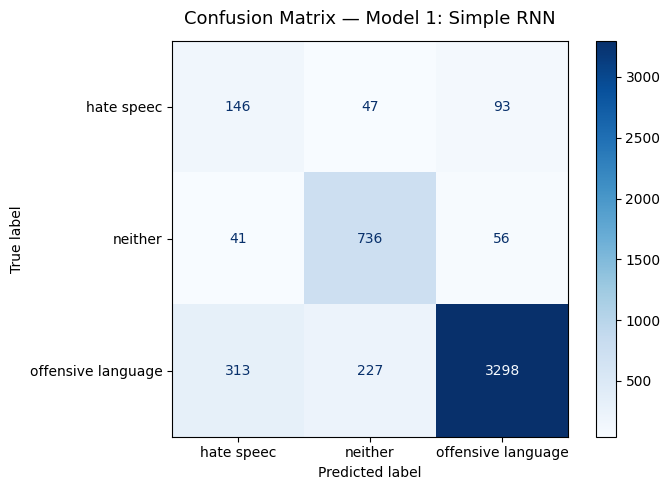

  Saved: model_1_simple_rnn_cm.png

  Evaluation: Model 2: LSTM

  Test Accuracy: 83.42%

  Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.28      0.66      0.39       286
           neither       0.79      0.84      0.81       833
offensive language       0.96      0.85      0.90      3838

          accuracy                           0.83      4957
         macro avg       0.67      0.78      0.70      4957
      weighted avg       0.89      0.83      0.85      4957



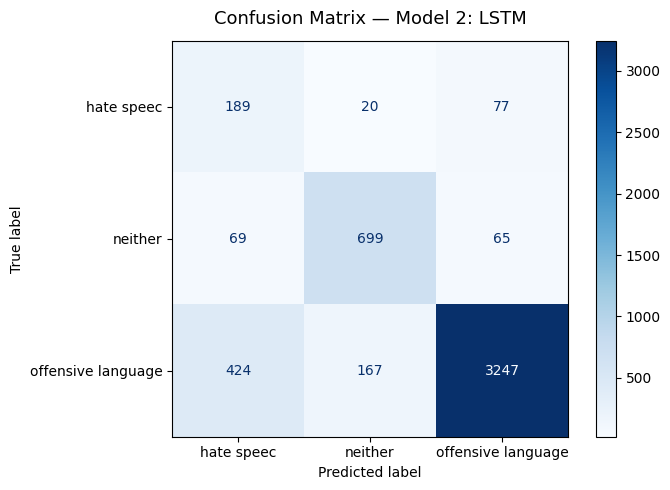

  Saved: model_2_lstm_cm.png

  Evaluation: Model 3: LSTM + GloVe

  Test Accuracy: 74.16%

  Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.10      0.13      0.11       286
           neither       0.49      0.69      0.57       833
offensive language       0.89      0.80      0.84      3838

          accuracy                           0.74      4957
         macro avg       0.50      0.54      0.51      4957
      weighted avg       0.78      0.74      0.76      4957



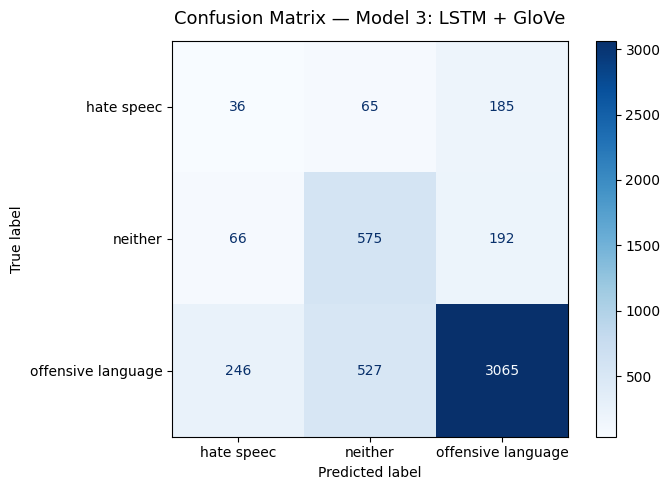

  Saved: model_3_lstm_+_glove_cm.png


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

CLASS_NAMES = list(le.classes_)

def evaluate_model(model, X_pad, y_enc, model_name, class_names):
    print('\n' + '=' * 55)
    print(f'  Evaluation: {model_name}')
    print('=' * 55)

    y_pred_probs = model.predict(X_pad, verbose=0)
    y_pred       = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_enc, y_pred)
    print(f'\n  Test Accuracy: {acc * 100:.2f}%')
    print('\n  Classification Report:')
    print(classification_report(y_enc, y_pred, target_names=class_names))

    cm  = confusion_matrix(y_enc, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=13, pad=12)
    plt.tight_layout()
    fname = model_name.replace(' ', '_').replace(':', '').lower() + '_cm.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {fname}')
    return acc, y_pred

acc1, pred1 = evaluate_model(model1_rnn,      X_test_pad, y_test_enc, 'Model 1: Simple RNN',   CLASS_NAMES)
acc2, pred2 = evaluate_model(model2_lstm,     X_test_pad, y_test_enc, 'Model 2: LSTM',          CLASS_NAMES)
acc3, pred3 = evaluate_model(model3_lstm_w2v, X_test_pad, y_test_enc, 'Model 3: LSTM + GloVe', CLASS_NAMES)


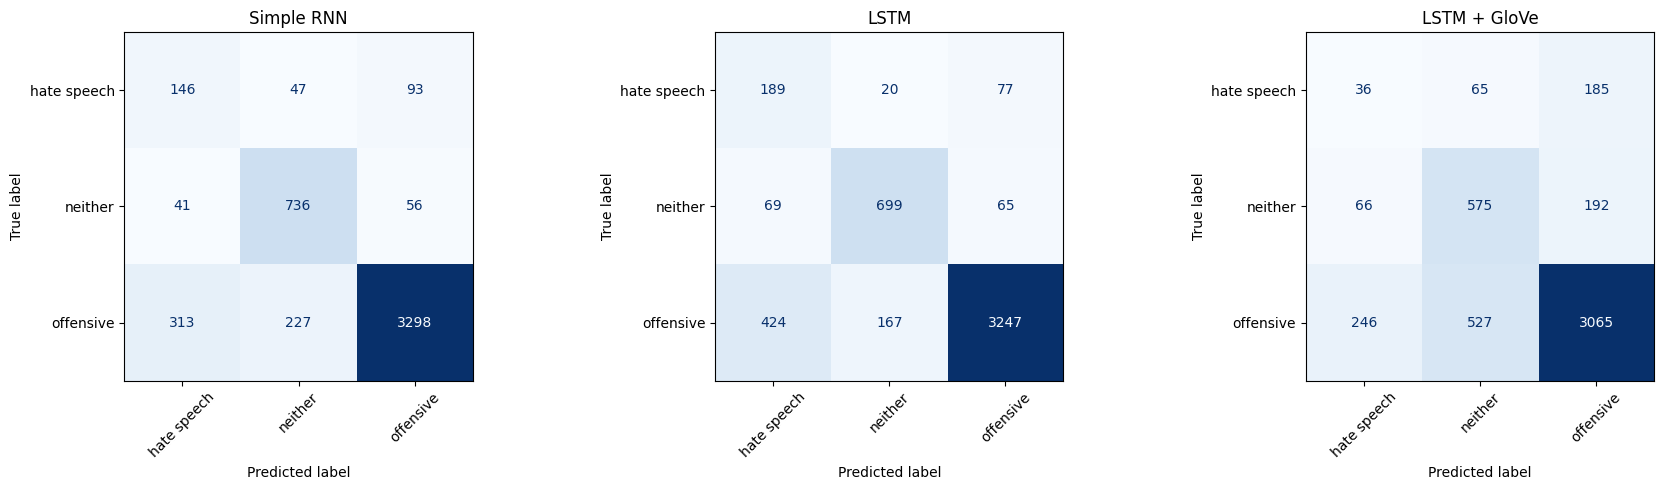

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = [(model1_rnn, 'Simple RNN'),
          (model2_lstm, 'LSTM'),
          (model3_lstm_w2v, 'LSTM + GloVe')]

class_names = ['hate speech', 'neither', 'offensive']

for ax, (model, name) in zip(axes, models):
    y_pred = np.argmax(model.predict(X_test_pad, verbose=0), axis=1)
    cm = confusion_matrix(y_test_enc, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}')
    ax.set_xticklabels(class_names, rotation=45)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 12: Side-by-Side Model Comparison

### Side-by-Side Model Comparison

This section presents a comparative analysis of all three models based on their test accuracy and training time. Bar plots are used to visually compare these key performance indicators.

*   **Accuracy Comparison**: A bar chart displaying the test accuracy (in percentage) for the Simple RNN, LSTM, and LSTM + GloVe models. This allows for a quick visual assessment of which model achieves the highest prediction performance.
*   **Training Time Comparison**: Another bar chart showing the training duration (in seconds) for each model. This is important for understanding the computational efficiency of different architectures, especially when considering deployment or training larger models.

By comparing both accuracy and training time, we can make informed decisions about the trade-off between model performance and computational cost. The combined plot is saved as `model_comparison.png`.

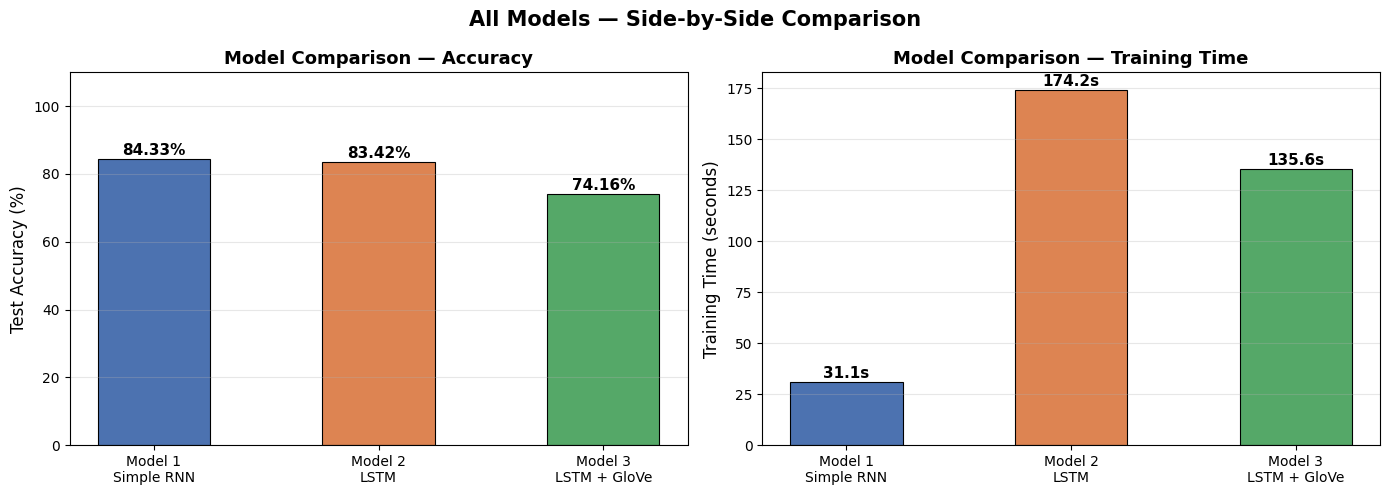

Saved: model_comparison.png


In [19]:
import matplotlib.pyplot as plt

labels = ['Model 1\nSimple RNN', 'Model 2\nLSTM', 'Model 3\nLSTM + GloVe']
accs   = [acc1 * 100, acc2 * 100, acc3 * 100]
times  = [time1, time2, time3]
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
bars1 = ax1.bar(labels, accs, color=colors, width=0.5, edgecolor='black', linewidth=0.8)
for bar, v in zip(bars1, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 110); ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title('Model Comparison — Accuracy', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Training time comparison
bars2 = ax2.bar(labels, times, color=colors, width=0.5, edgecolor='black', linewidth=0.8)
for bar, t in zip(bars2, times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{t:.1f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_ylabel('Training Time (seconds)', fontsize=12)
ax2.set_title('Model Comparison — Training Time', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('All Models — Side-by-Side Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')


## Step 13: Error Analysis and Suggested Improvements

### Error Analysis and Suggested Improvements

This section delves into analyzing the errors made by the best-performing model (in this case, Model 3: LSTM + GloVe) to understand its limitations and identify areas for improvement.

1.  **Misclassified Examples**: It first identifies and prints the total number and percentage of misclassified examples. Then, it shows a few sample misclassified texts, comparing the true label with the model's prediction. This qualitative analysis helps to understand *why* certain predictions were wrong.

2.  **Reasons for Misclassification**: A comprehensive list of common reasons for misclassification in text classification tasks is provided, specific to this problem:
    *   **Class Imbalance**: As identified earlier, unequal distribution of classes can bias the model.
    *   **Ambiguous Language**: The fine line between offensive language and hate speech, or even neither, can be challenging for models.
    *   **Context Loss**: Truncation during padding might remove critical contextual words.
    *   **OOV (Out-Of-Vocabulary) Tokens**: Words not seen during tokenization are replaced with a generic token, losing their meaning.
    *   **GloVe Domain Gap**: GloVe embeddings are trained on general text (Wikipedia, news), which might not capture the nuances and slang of social media language as effectively.

3.  **Suggested Improvements**: Based on the error analysis, several actionable improvements are suggested to enhance model performance in future iterations:
    *   **`class_weight`**: To address class imbalance during training.
    *   **Glove-Twitter Embeddings**: Using embeddings specifically trained on Twitter data might better capture social media language.
    *   **Bidirectional LSTM**: To process sequences in both directions, capturing richer context.
    *   **Dropout Layers**: To mitigate overfitting.
    *   **Hyperparameter Tuning**: Optimizing learning rate, LSTM units, and batch size can lead to better results.

In [20]:
import numpy as np

# Use best model predictions for error analysis (change to pred1/pred2 if needed)
best_pred = pred1
best_name = 'simple rnn'

misclassified_idx = np.where(best_pred != y_test_enc)[0]
print(f'Total misclassified ({best_name}): {len(misclassified_idx)} / {len(y_test_enc)}')
print(f'Error rate: {len(misclassified_idx)/len(y_test_enc)*100:.2f}%')

print('\n' + '='*70)
print('Sample Misclassified Examples')
print('='*70)

for i, idx in enumerate(misclassified_idx[:5]):
    true_lbl = le.classes_[y_test_enc[idx]]
    pred_lbl = le.classes_[best_pred[idx]]
    print(f'\nExample {i+1}:')
    print(f'  Text      : {X_test[idx][:120]}...')
    print(f'  True Label: {true_lbl}')
    print(f'  Predicted : {pred_lbl}')
    print(f'  Analysis  : Model confused "{true_lbl}" for "{pred_lbl}".')

print('\n' + '='*70)
print('Reasons for Misclassification:')
print('='*70)
reasons = '''
1. Class Imbalance   : More samples of one class bias the model toward majority predictions.
2. Ambiguous Language: Hate speech and offensive language share similar vocabulary.
3. Context Loss      : Padding/truncation removes surrounding context clues.
4. OOV Tokens        : Out-of-vocabulary words are replaced with <OOV>, losing meaning.
5. GloVe Domain Gap  : GloVe was trained on news/Wikipedia, not social media slang.
'''
print(reasons)

print('Suggested Improvements:')
improvements = '''
- Use class_weight in model.fit() to handle imbalanced classes.
- Use glove-twitter-100 embeddings (trained on tweets) for better coverage.
- Use Bidirectional LSTM to capture context from both directions.
- Add Dropout layers to reduce overfitting.
- Hyperparameter tuning: learning rate, LSTM units, batch size.
'''
print(improvements)


Total misclassified (simple rnn): 777 / 4957
Error rate: 15.67%

Sample Misclassified Examples

Example 1:
  Text      : new nigga hipster hypebeasts love faggot as bright color nike keep giving them they want smh...
  True Label: hate speec
  Predicted : offensive language
  Analysis  : Model confused "hate speec" for "offensive language".

Example 2:
  Text      : hey cunt miss you...
  True Label: offensive language
  Predicted : hate speec
  Analysis  : Model confused "offensive language" for "hate speec".

Example 3:
  Text      : they hardly get sexso opportunity sick present their giving you pussyand boy they generous...
  True Label: offensive language
  Predicted : hate speec
  Analysis  : Model confused "offensive language" for "hate speec".

Example 4:
  Text      : full nigger...
  True Label: offensive language
  Predicted : hate speec
  Analysis  : Model confused "offensive language" for "hate speec".

Example 5:
  Text      : nigga send hate thru bitch...
  True Label: o

## Step 14: Interactive Demo with Gradio

### Interactive Demo with Gradio

This section creates a simple web-based interface using `Gradio` to demonstrate the best-performing model (Model 3: LSTM + GloVe Embeddings) in real-time. This allows users to input custom text and instantly get a prediction from the model.

1.  **`predict_text(user_input)` Function**: This function takes raw text input from the user, applies the same `clean_text` preprocessing, tokenization, and padding steps as the training data, and then feeds it to the `gui_model` to get predictions. It returns the predicted label, confidence, and a dictionary of probabilities for all classes.

2.  **`gr.Blocks` Interface**:
    *   **`gr.Markdown`**: Used for displaying titles and informational text.
    *   **`gr.Textbox`**: An input component where the user types or pastes text.
    *   **`gr.Button`**: Triggers the `predict_text` function when clicked.
    *   **`gr.Markdown(label='Result')`**: Displays the model's final prediction and overall confidence.
    *   **`gr.Label(num_top_classes=3)`**: Shows the probability distribution across all three classes, providing more detailed confidence scores.

3.  **`submit_btn.click(...)`**: Connects the button click event to the `predict_text` function, passing the `text_input` and updating `result_out` and `confidence_out`.

4.  **`gr.Examples`**: Provides predefined example inputs for users to quickly test the model.

5.  **`demo.launch(share=True)`**: Starts the Gradio interface. `share=True` generates a public URL, making the demo accessible to others for a limited time (useful for Colab). This allows for easy interaction and testing of the model's practical application.

In [21]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Using the best model for the GUI
gui_model      = model3_lstm_w2v
gui_model_name = 'LSTM + GloVe Embeddings'

def predict_text(user_input):
    if not user_input.strip():
        return 'Please enter some text.', {}

    cleaned = clean_text(user_input)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    probs           = gui_model.predict(padded, verbose=0)[0]
    predicted_idx   = np.argmax(probs)
    predicted_label = le.classes_[predicted_idx]
    confidence      = probs[predicted_idx] * 100

    conf_dict = {le.classes_[i]: float(probs[i]) for i in range(len(le.classes_))}
    result    = f'**Prediction:** {predicted_label.upper()}  |  **Confidence:** {confidence:.1f}%'
    return result, conf_dict

with gr.Blocks(title='Hate Speech Detector') as demo:
    gr.Markdown('# Hate Speech & Offensive Language Detector')
    gr.Markdown(f'Powered by **{gui_model_name}**')

    with gr.Row():
        with gr.Column():
            text_input = gr.Textbox(
                lines=4,
                placeholder='Type or paste a tweet / sentence here...',
                label='Input Text'
            )
            submit_btn = gr.Button('Classify', variant='primary')
        with gr.Column():
            result_out     = gr.Markdown(label='Result')
            confidence_out = gr.Label(num_top_classes=3, label='Confidence Scores')

    submit_btn.click(fn=predict_text,
                     inputs=text_input,
                     outputs=[result_out, confidence_out])

    gr.Examples(
        examples=[
            ['I hate all people like you, you should disappear.'],
            ['This movie was absolutely terrible, what a waste of time!'],
            ['Had a wonderful day at the park with my family today.'],
        ],
        inputs=text_input
    )

demo.launch(share=True)   # share=True gives a public Colab URL


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2bdebdeb34e200a2e4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
